<a href="https://colab.research.google.com/github/T31SHA/Nairobi_Flood_Guard-AI/blob/ft-Carl/Models/Notebooks/logistic_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, auc, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Load the feature matrix
wards = gpd.read_file("floods.gpkg")

# Creating a derived feature column
wards['elevation_range_m'] = wards['elevation_max_m'] - wards['elevation_min_m']


# Drop geometry and metadata for modelling — keep only numeric features and target
feature_cols = [
    'pop2009',
    'rain_cumulative_mm',
    'rain_max_daily_mm',
    'rain_preflood_7d_mm',
    'elevation_mean_m',
    'elevation_min_m',
    'slope_mean_deg',
    'elevation_max_m',
    'elevation_range_m',
]

X = wards[feature_cols]
y = wards['flooded']

print(f"Feature matrix shape : {X.shape}")
print(f"Class distribution   :\n{y.value_counts(normalize=True)}")
print(f"\nMissing values:\n{X.isnull().sum()}")

Feature matrix shape : (1450, 9)
Class distribution   :
flooded
0    0.788276
1    0.211724
Name: proportion, dtype: float64

Missing values:
pop2009                0
rain_cumulative_mm     0
rain_max_daily_mm      0
rain_preflood_7d_mm    0
elevation_mean_m       0
elevation_min_m        0
slope_mean_deg         0
elevation_max_m        0
elevation_range_m      0
dtype: int64


In [3]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1015, 9)
Testing set shape: (435, 9)


In [4]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression
# Create logistic regression model
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train model
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [8]:
# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Probabilities for ROC curve
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [9]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       343
           1       0.47      0.74      0.57        92

    accuracy                           0.77       435
   macro avg       0.69      0.76      0.71       435
weighted avg       0.82      0.77      0.78       435



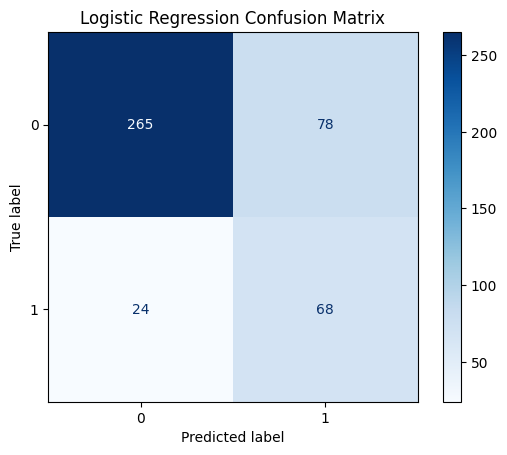

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_reg.classes_
)

disp.plot(cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.show()

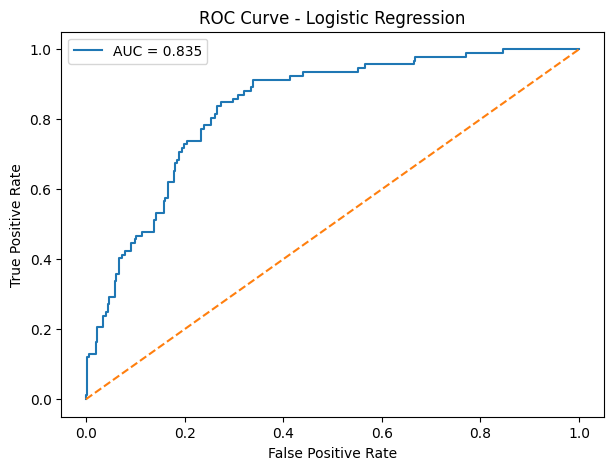

ROC-AUC Score: 0.834706553428825


In [11]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

The Logistic Regression model achieved an ROC-AUC score of 0.83, indicating good ability to distinguish between flooded and non-flooded wards.

The model achieved higher performance for the non-flooded class than the flooded class, which is expected because the dataset is imbalanced. However, the recall score of 0.74 for flooded wards suggests that the model is able to correctly identify most flood-prone wards.

This is important for disaster preparedness because failing to identify a flooded ward may have more severe consequences than generating a false warning.

Although precision for flooded wards remains moderate, the model provides a useful baseline for flood risk prediction using rainfall and terrain-related features.